In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [12]:
# Load crude oil price data
crude_oil = pd.read_csv("data/crude_oil_prices.csv", parse_dates=['Date'], index_col='Date')

# Use the price column
data = crude_oil['Value']

# Resample to monthly average
data = data.resample('M').mean()

C:\Users\Spike\AppData\Local\Temp\ipykernel_47888\120187543.py:8: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  data = data.resample('M').mean()


In [8]:
returns = np.log(data / data.shift(1)).dropna()

In [9]:
# Calculate variance, standard deviation, and standard error for crude oil returns
var = np.var(returns, ddof=1)
std_dev = np.sqrt(var)
se = std_dev / np.sqrt(len(returns))

print(f"Variance of Crude Oil Returns: {var:.6f}")
print(f"Standard Deviation: {std_dev:.6f}")
print(f"Standard Error: {se:.6f}")

Variance of Crude Oil Returns: 0.006747
Standard Deviation: 0.082140
Standard Error: 0.002650


<Axes: title={'center': 'Rolling 12-Month Variance of Crude Oil Returns'}, xlabel='Date'>

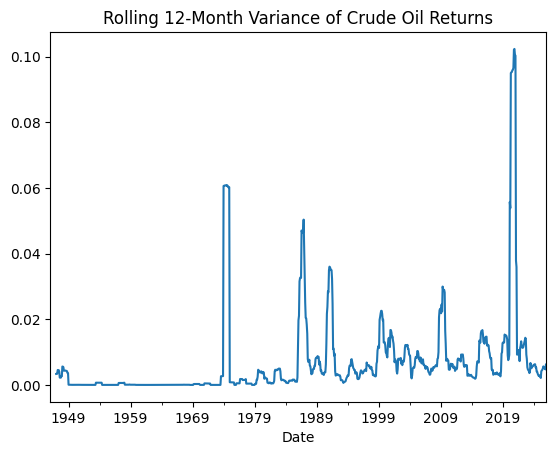

In [10]:
rolling_window = 12  # months
rolling_var = returns.rolling(rolling_window).var()

rolling_var.plot(title="Rolling 12-Month Variance of Crude Oil Returns")

In [14]:
# Calculate average 12-month rolling variance across the entire dataset
avg_rolling_var_all = rolling_var.mean()
print(f"Average 12-Month Rolling Variance (Entire Dataset): {avg_rolling_var_all:.6f}")

# Calculate average 12-month rolling variance for the last 10 years
last_10_years = rolling_var.index.max() - pd.DateOffset(years=10)
avg_rolling_var_10y = rolling_var.loc[rolling_var.index >= last_10_years].mean()
print(f"Average 12-Month Rolling Variance (Last 10 Years): {avg_rolling_var_10y:.6f}")

# Calculate average 12-month rolling variance for the last 5 years
last_5_years = rolling_var.index.max() - pd.DateOffset(years=5)
avg_rolling_var_5y = rolling_var.loc[rolling_var.index >= last_5_years].mean()
print(f"Average 12-Month Rolling Variance (Last 5 Years): {avg_rolling_var_5y:.6f}")

# Calculate average 12-month rolling variance for the last 2 years
last_2_years = rolling_var.index.max() - pd.DateOffset(years=2)
avg_rolling_var_2y = rolling_var.loc[rolling_var.index >= last_2_years].mean()
print(f"Average 12-Month Rolling Variance (Last 2 Years): {avg_rolling_var_2y:.6f}")

Average 12-Month Rolling Variance (Entire Dataset): 0.006831
Average 12-Month Rolling Variance (Last 10 Years): 0.016447
Average 12-Month Rolling Variance (Last 5 Years): 0.009456
Average 12-Month Rolling Variance (Last 2 Years): 0.004547
